In [1]:
# Original Author: Christina Bukas
# Modified by: Abdulkader Ghandoura

In [2]:
# Render matplotlib plots directly in the notebook
%matplotlib inline

# Load the autoreload extension, which watches for changes in imported modules
%load_ext autoreload

# Automatically reload all modules before executing each cell
%autoreload 2

In [3]:
import os
from pathlib import Path

from matplotlib import pyplot as plt
import numpy as np

from skimage.transform import rescale, resize
from skimage.color import gray2rgb
from aicsimageio import imread

import torch
import torchvision.transforms as T

import onnxruntime as ort

from mmdet.apis import init_detector
from mmdeploy.apis.pytorch2onnx import torch2onnx

MODELS: ['rtmdet_l_organoid_best_coco_bbox_mAP_epoch_323.pth', 'yolov3_416_organoid_best_coco_bbox_mAP_epoch_27.pth', 'ssd_organoid_best_coco_bbox_mAP_epoch_86.pth', 'faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68.pth', 'yolov3_416_organoid_best_coco_bbox_mAP_epoch_27.onnx', 'faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68.onnx', 'faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68_backup.onnx']


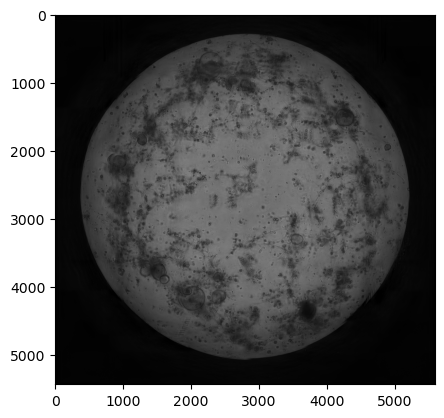

In [4]:
models_dir = Path.home() / '.cache/napari-organoid-counter/models'
yolo_model_path = os.path.join(models_dir, 'yolov3_416_organoid_best_coco_bbox_mAP_epoch_27.pth')
rtmdet_model_path = os.path.join(models_dir, 'rtmdet_l_organoid_best_coco_bbox_mAP_epoch_323.pth')
ssd_model_path = os.path.join(models_dir, 'ssd_organoid_best_coco_bbox_mAP_epoch_86.pth')
fasterrcnn_model_path = os.path.join(models_dir, 'faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68.pth')

config_path = '/Users/abdulkaderghandoura/miniforge3/envs/napari/lib/python3.10/site-packages/mmdet/.mim/configs'
yolo_config_dst = os.path.join(config_path,'yolo/yolov3_416_organoid.py')
rtmdet_config_dst = os.path.join(config_path, 'rtmdet/rtmdet_l_organoid.py')
ssd_config_dst = os.path.join(config_path, 'ssd/ssd_organoid.py')
fasterrcnn_config_dst = os.path.join(config_path, 'faster_rcnn/faster-rcnn_r50_fpn_organoid.py')

img_path = '/Users/abdulkaderghandoura/Downloads/MultiOrg/Annotated_by_Gowtham/Images/GoBo032_Control_Plate_PCR_TileScan_1_A_10_Merged_EDF001_ch00.tif'


list_models = os.listdir(models_dir)
print("MODELS:", list_models)


img = imread(img_path)[0,0,0]
plt.imshow(img, cmap='gray')
plt.show()

def squeeze_img(img):
    """ Squeeze image - all dims that have size one will be removed """
    return np.squeeze(img)

def prepare_img(test_img, step, window_size, rescale_factor):
    """ The original image is prepared for running model inference """
    # squeeze and resize image
    test_img = squeeze_img(test_img)
    test_img = rescale(test_img, rescale_factor, preserve_range=True)
    img_height, img_width = test_img.shape
    # pad image
    pad_x = (img_height//step)*step + window_size - img_height
    pad_y = (img_width//step)*step + window_size - img_width
    test_img = np.pad(test_img, ((0, int(pad_x)), (0, int(pad_y))), mode='edge')
    # normalise and convert to RGB - model input has size 3
    test_img = (test_img-np.min(test_img))/(np.max(test_img)-np.min(test_img)) 
    test_img = (255*test_img).astype(np.uint8)
    test_img = gray2rgb(test_img) #[H,W,C]

    # convert from RGB to GBR - expected from DetInferencer 
    test_img = test_img[..., ::-1] 
    '''
    test_img = test_img.astype(np.float32) / 255.0
    # HWC -> CHW
    test_img = np.transpose(test_img, (2, 0, 1))
    # Add batch dimension
    test_img = np.expand_dims(test_img, axis=0)
    '''
    return test_img, img_height, img_width

def resize_keep_ratio_numpy(img, scale=(416, 416)):
    """
    Resize a numpy array [B, C, H, W] keeping aspect ratio using skimage.

    Args:
        img (np.ndarray): shape [B, C, H, W]
        scale (tuple): target maximum (w, h), e.g. (416, 416)

    Returns:
        np.ndarray: resized array [B, C, new_h, new_w]
        (int, int): new size (new_h, new_w)
        float: scale factor
    """
    assert img.ndim == 4, "Expected input shape [B, C, H, W]"
    B, C, H, W = img.shape
    target_w, target_h = scale

    # compute scale factor
    scale_factor = min(target_w / W, target_h / H)
    new_w, new_h = int(W * scale_factor), int(H * scale_factor)

    resized_batch = []
    for i in range(B):
        # [C, H, W] → [H, W, C]
        img_hwc = np.transpose(img[i], (1, 2, 0))
        resized = resize(img_hwc, (new_h, new_w), order=1, anti_aliasing=True)
        # back to [C, H, W]
        resized_chw = np.transpose(resized, (2, 0, 1))
        resized_batch.append(resized_chw.astype(np.float32))

    resized_batch = np.stack(resized_batch, axis=0)
    return resized_batch 

In [5]:
model_checkpoint = fasterrcnn_model_path
model_cfg = fasterrcnn_config_dst
save_file = 'faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68.onnx'
#import mmdeploy
#print(mmdeploy.__version__)

## Export model to onnx format

In [6]:


#deploy_cfg = './configs/mmdet/detection/yolov3_partition_onnxruntime_static.py' #yolov3_d53_320_coco_onnxruntime_dynamic.py'
deploy_cfg = str(Path.home() / 'workspace/mmdeploy/configs/mmdet/detection/detection_onnxruntime_dynamic.py')
print(deploy_cfg)
work_dir = '.'

'''
img (str | np.ndarray | torch.Tensor): Input image used to assist converting model.
'''

img_path = '/Users/abdulkaderghandoura/Downloads/MultiOrg/Annotated_by_Gowtham/Images/GoBo032_Control_Plate_PCR_TileScan_1_A_10_Merged_EDF001_ch00.tif'
img = imread(img_path)[0,0,0]

img_r, _, _ = prepare_img(img, step=1, window_size=2048, rescale_factor=1)
print(img_r.shape)
#img_r = resize_keep_ratio_numpy(img_r)

torch2onnx(img_r[:2048,:2048,:],
            work_dir,
            save_file,
            deploy_cfg,
            model_cfg,
            model_checkpoint, 
            'cpu')

/Users/abdulkaderghandoura/workspace/mmdeploy/configs/mmdet/detection/detection_onnxruntime_dynamic.py
(7486, 7630, 3)
11/27 13:29:54 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "Codebases" registry tree. As a workaround, the current "Codebases" registry in "mmdeploy" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
11/27 13:29:54 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "mmdet_tasks" registry tree. As a workaround, the current "mmdet_tasks" registry in "mmdeploy" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
Loads checkpoint by local backend from path: /Users/abdulkaderghandoura/.cache/napari-organoid-counter/models/faster-rcnn_r50_fpn_organoid_best_coco_bb

/Users/abdulkaderghandoura/workspace/mmdeploy/mmdeploy/core/optimizers/function_marker.py:160: TracerWarning: Converting a tensor to a Python integer might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  ys_shape = tuple(int(s) for s in ys.shape)
/Users/abdulkaderghandoura/miniforge3/envs/napari/lib/python3.10/site-packages/mmdet/models/dense_heads/anchor_head.py:115: UserWarning: DeprecationWarning: anchor_generator is deprecated, please use "prior_generator" instead
  warnings.warn('DeprecationWarning: anchor_generator is deprecated, '
/Users/abdulkaderghandoura/miniforge3/envs/napari/lib/python3.10/site-packages/mmdet/models/task_modules/prior_generators/anchor_generator.py:356: UserWarning: ``grid_anchors`` would be deprecated soon. Please use ``grid_priors`` 
  warnings.warn('``grid_anchors`` would be deprecated soon. '
/User

11/27 13:29:59 - mmengine - INFO - Execute onnx optimize passes.
11/27 13:29:59 - mmengine - WARNING - Can not optimize model, please build torchscipt extension.
More details: https://github.com/open-mmlab/mmdeploy/tree/main/docs/en/experimental/onnx_optimizer.md


## Test exported onnx model

In [7]:
onnx_model = save_file #'model.onnx'
session = ort.InferenceSession(onnx_model, providers=["CPUExecutionProvider"])
# Get input/output names
input_name = session.get_inputs()[0].name
output_names = [o.name for o in session.get_outputs()]

# Preprocess
img = imread(img_path)[0,0,0]
img_r, _, _ = prepare_img(img, step=1, window_size=2048, rescale_factor=1)
img_r = img_r.astype(np.float32) / 255.0


# HWC -> CHW
img_r = np.transpose(img_r, (2, 0, 1))
# Add batch dimension
img_r = np.expand_dims(img_r, axis=0)
print(img_r.shape)
# Run inference
outputs = session.run(output_names, {input_name: img_r[:,:,:2048,:2048]})

dets, labels = outputs
for det, label in zip(dets[0], labels[0]):
    x1, y1, x2, y2, score = det
    if score > 0.3:  # confidence threshold
        print(f"Class {int(label)}, Score {score:.2f}, Box [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")


(1, 3, 7486, 7630)
Class 0, Score 0.99, Box [1195, 1746, 1359, 1928]
Class 0, Score 0.99, Box [803, 1434, 853, 1484]
Class 0, Score 0.97, Box [1023, 1442, 1061, 1477]
Class 0, Score 0.95, Box [890, 1348, 940, 1398]
Class 0, Score 0.95, Box [1687, 1594, 1746, 1652]
Class 0, Score 0.94, Box [1037, 1156, 1074, 1197]
Class 0, Score 0.89, Box [974, 1726, 1023, 1775]
Class 0, Score 0.85, Box [1616, 1717, 1656, 1758]
Class 0, Score 0.82, Box [769, 1859, 799, 1891]
Class 0, Score 0.73, Box [1461, 1166, 1498, 1206]
Class 0, Score 0.69, Box [1043, 1384, 1079, 1421]
Class 0, Score 0.68, Box [1283, 1097, 1325, 1138]
Class 0, Score 0.66, Box [1617, 1578, 1665, 1634]
Class 0, Score 0.64, Box [899, 1823, 943, 1875]
Class 0, Score 0.62, Box [1440, 761, 1473, 793]
Class 0, Score 0.59, Box [1008, 1196, 1039, 1224]
Class 0, Score 0.57, Box [728, 1879, 762, 1913]
Class 0, Score 0.50, Box [1169, 1495, 1206, 1535]
Class 0, Score 0.49, Box [1550, 1091, 1578, 1121]
Class 0, Score 0.45, Box [1985, 1328, 2026, 

## Find which transformations where used on image in DetInferencer based on the config


In [8]:
from mmengine import Config
from mmdet.apis import DetInferencer

# Load config
cfg = "/Users/abdulkaderghandoura/miniforge3/envs/napari/lib/python3.10/site-packages/mmdet/.mim/configs/yolo/yolov3_416_organoid.py"
cfg = Config.fromfile(cfg)
# Print the test pipeline used for inference
print(cfg.test_dataloader.dataset.pipeline)

[{'type': 'LoadImageFromFile', 'backend_args': None}, {'type': 'Resize', 'scale': (416, 416), 'keep_ratio': True}, {'type': 'LoadAnnotations', 'with_bbox': True}, {'type': 'PackDetInputs', 'meta_keys': ('img_id', 'img_path', 'ori_shape', 'img_shape', 'scale_factor')}]


In [9]:
import mmdeploy
from pathlib import Path

print(f"mmdeploy location: {mmdeploy.__file__}")

# Check for the optimizer library
mmdeploy_root = Path(mmdeploy.__file__).parent
lib_dir = mmdeploy_root / "lib"

print(f"\nLib directory: {lib_dir}")
print(f"Exists: {lib_dir.exists()}")

if lib_dir.exists():
    print("\nLibraries found:")
    for lib in lib_dir.glob("*"):
        print(f"  - {lib.name}")

mmdeploy location: /Users/abdulkaderghandoura/workspace/mmdeploy/mmdeploy/__init__.py

Lib directory: /Users/abdulkaderghandoura/workspace/mmdeploy/mmdeploy/lib
Exists: True

Libraries found:
  - libmmdeploy_torchscript_ops.so


In [10]:
from mmdeploy.apis.pytorch2onnx import torch2onnx

# Export configuration
deploy_cfg = str(Path.home() / 'workspace/mmdeploy/configs/mmdet/detection/detection_onnxruntime_dynamic.py')

work_dir = '.'
model_ckpts = [yolo_model_path, rtmdet_model_path, ssd_model_path, fasterrcnn_model_path]
model_cfgs = [yolo_config_dst, rtmdet_config_dst, ssd_config_dst, fasterrcnn_config_dst]
save_files = [
    'yolov3_416_organoid_best_coco_bbox_mAP_epoch_27.onnx',
    'rtmdet_l_organoid_best_coco_bbox_mAP_epoch_323.onnx',
    'ssd_organoid_best_coco_bbox_mAP_epoch_86.onnx',
    'faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68.onnx'
]

# Prepare input image
img_path = '/Users/abdulkaderghandoura/Downloads/MultiOrg/Annotated_by_Gowtham/Images/GoBo032_Control_Plate_PCR_TileScan_1_A_10_Merged_EDF001_ch00.tif'
img = imread(img_path)[0,0,0]
img_r, _, _ = prepare_img(img, step=1, window_size=2048, rescale_factor=1)

print(f"Input image shape: {img_r.shape}")

for model_checkpoint, model_cfg, save_file in zip(model_ckpts, model_cfgs, save_files):        
    # Export to ONNX - this will use optimizations if available
    torch2onnx(
        img_r[:2048, :2048, :],
        work_dir,
        save_file,
        deploy_cfg,
        model_cfg,
        model_checkpoint, 
        'cpu'
    )
    
    print(f"\n✓ ONNX model exported to: {save_file}")
    print("Check the logs above - if you see 'Execute onnx optimize passes' without warnings, optimization is working!")

Input image shape: (7486, 7630, 3)
Loads checkpoint by local backend from path: /Users/abdulkaderghandoura/.cache/napari-organoid-counter/models/yolov3_416_organoid_best_coco_bbox_mAP_epoch_27.pth
11/27 13:30:33 - mmengine - INFO - Export PyTorch model to ONNX: ./yolov3_416_organoid_best_coco_bbox_mAP_epoch_27.onnx.


/Users/abdulkaderghandoura/workspace/mmdeploy/mmdeploy/core/optimizers/function_marker.py:160: TracerWarning: Converting a tensor to a Python integer might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  ys_shape = tuple(int(s) for s in ys.shape)
/Users/abdulkaderghandoura/miniforge3/envs/napari/lib/python3.10/site-packages/mmdet/models/task_modules/prior_generators/anchor_generator.py:356: UserWarning: ``grid_anchors`` would be deprecated soon. Please use ``grid_priors`` 
  warnings.warn('``grid_anchors`` would be deprecated soon. '
/Users/abdulkaderghandoura/miniforge3/envs/napari/lib/python3.10/site-packages/mmdet/models/task_modules/prior_generators/anchor_generator.py:392: UserWarning: ``single_level_grid_anchors`` would be deprecated soon. Please use ``single_level_grid_priors`` 
  warnings.warn(
/Users/abdulkaderghandoura/m

11/27 13:30:36 - mmengine - INFO - Execute onnx optimize passes.

✓ ONNX model exported to: yolov3_416_organoid_best_coco_bbox_mAP_epoch_27.onnx
Check the logs above - if you see 'Execute onnx optimize passes' without warnings, optimization is working!
Loads checkpoint by local backend from path: /Users/abdulkaderghandoura/.cache/napari-organoid-counter/models/rtmdet_l_organoid_best_coco_bbox_mAP_epoch_323.pth
11/27 13:30:37 - mmengine - INFO - Export PyTorch model to ONNX: ./rtmdet_l_organoid_best_coco_bbox_mAP_epoch_323.onnx.


/Users/abdulkaderghandoura/miniforge3/envs/napari/lib/python3.10/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1719361051023/work/aten/src/ATen/native/TensorShape.cpp:3588.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/Users/abdulkaderghandoura/workspace/mmdeploy/mmdeploy/pytorch/functions/topk.py:28: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  k = torch.tensor(k, device=input.device, dtype=torch.long)


11/27 13:30:42 - mmengine - INFO - Execute onnx optimize passes.

✓ ONNX model exported to: rtmdet_l_organoid_best_coco_bbox_mAP_epoch_323.onnx
Check the logs above - if you see 'Execute onnx optimize passes' without warnings, optimization is working!
Loads checkpoint by local backend from path: /Users/abdulkaderghandoura/.cache/napari-organoid-counter/models/ssd_organoid_best_coco_bbox_mAP_epoch_86.pth
11/27 13:30:43 - mmengine - INFO - Export PyTorch model to ONNX: ./ssd_organoid_best_coco_bbox_mAP_epoch_86.onnx.


/Users/abdulkaderghandoura/workspace/mmdeploy/mmdeploy/codebase/mmdet/models/dense_heads/base_dense_head.py:109: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert cls_score.size()[-2:] == bbox_pred.size()[-2:]
/Users/abdulkaderghandoura/workspace/mmdeploy/mmdeploy/pytorch/functions/topk.py:28: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  k = torch.tensor(k, device=input.device, dtype=torch.long)
/Users/abdulkaderghandoura/workspace/mmdeploy/mmdeploy/codebase/mmdet/models/task_modules/coders/delta_xywh_bbox_code

11/27 13:30:46 - mmengine - INFO - Execute onnx optimize passes.

✓ ONNX model exported to: ssd_organoid_best_coco_bbox_mAP_epoch_86.onnx
Check the logs above - if you see 'Execute onnx optimize passes' without warnings, optimization is working!
Loads checkpoint by local backend from path: /Users/abdulkaderghandoura/.cache/napari-organoid-counter/models/faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68.pth
11/27 13:30:46 - mmengine - INFO - Export PyTorch model to ONNX: ./faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68.onnx.


/Users/abdulkaderghandoura/miniforge3/envs/napari/lib/python3.10/site-packages/mmdet/models/dense_heads/anchor_head.py:115: UserWarning: DeprecationWarning: anchor_generator is deprecated, please use "prior_generator" instead
  warnings.warn('DeprecationWarning: anchor_generator is deprecated, '
/Users/abdulkaderghandoura/workspace/mmdeploy/mmdeploy/codebase/mmdet/models/dense_heads/rpn_head.py:89: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert cls_score.size()[-2:] == bbox_pred.size()[-2:]
/Users/abdulkaderghandoura/workspace/mmdeploy/mmdeploy/pytorch/functions/topk.py:28: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would

11/27 13:30:51 - mmengine - INFO - Execute onnx optimize passes.

✓ ONNX model exported to: faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68.onnx
Check the logs above - if you see 'Execute onnx optimize passes' without warnings, optimization is working!


In [ ]:
# from mmdeploy.apis.pytorch2onnx import torch2onnx

# # Export configuration
# deploy_cfg = str(Path.home() / 'workspace/mmdeploy/configs/mmdet/detection/detection_onnxruntime_dynamic.py')

# model_checkpoint = fasterrcnn_model_path
# model_cfg = fasterrcnn_config_dst
# work_dir = '.'
# save_file = 'faster-rcnn_r50_fpn_organoid_best_coco_bbox_mAP_epoch_68.onnx'

# # Prepare input image
# img_path = '/Users/abdulkaderghandoura/Downloads/MultiOrg/Annotated_by_Gowtham/Images/GoBo032_Control_Plate_PCR_TileScan_1_A_10_Merged_EDF001_ch00.tif'
# img = imread(img_path)[0,0,0]
# img_r, _, _ = prepare_img(img, step=1, window_size=2048, rescale_factor=1)

# print(f"Input image shape: {img_r.shape}")

# # Export to ONNX - this will use optimizations if available
# torch2onnx(
#     img_r[:2048, :2048, :],
#     work_dir,
#     save_file,
#     deploy_cfg,
#     model_cfg,
#     model_checkpoint, 
#     'cpu'
# )

# print(f"\n✓ ONNX model exported to: {save_file}")
# print("Check the logs above - if you see 'Execute onnx optimize passes' without warnings, optimization is working!")

## Another mmdeploy try - didn't work

In [ ]:
from mmdeploy.apis import build_task_processor
from mmengine.config import Config

# Load configs
deploy_cfg = './mmdeploy/configs/mmdet/detection/yolov3_partition_onnxruntime_static.py' #yolov3_d53_320_coco_onnxruntime_dynamic.py' #yolov3_partition_onnxruntime_static.py
model_cfg = '/Users/christinabukas/miniconda3/envs/noc-test3/lib/python3.10/site-packages/mmdet/.mim/configs/yolo/yolov3_416_organoid.py'
checkpoint = '/Users/christinabukas/.cache/napari-organoid-counter/models/yolov3_416_organoid_best_coco_bbox_mAP_epoch_27.pth'

model_cfg = Config.fromfile(model_cfg)
deploy_cfg = Config.fromfile(deploy_cfg)

# Build the task processor for deployment
task_processor = build_task_processor(model_cfg, deploy_cfg, device='cpu')

# Export the model
task_processor.export(deploy_cfg, checkpoint, output_dir='deploy_output', device='cpu')

## Using torchscript to export model - this didn't work

In [ ]:
# Dummy input (batch, C, H, W)
example_img = torch.randn(1, 3, 384, 416).to("cpu")
# Build model
model = init_detector(config_dst, yolo_model_path, device="cpu")
model.eval()
# Trace the model
traced = torch.jit.trace(model, example_img)
traced.save("model_traced.pt")


# Load TorchScript model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = torch.jit.load("model_traced.pt", map_location=device)
model.eval()


def preprocess_image(arr: np.ndarray, size=(383, 416)):
    """
    Convert a numpy image (HWC or CHW) into a PyTorch tensor 
    with shape [1, 3, H, W], resized to `size`.
    """
    if arr.ndim == 3 and arr.shape[0] == 3:  
        # CHW -> HWC
        arr = np.transpose(arr, (1, 2, 0))
    
    # Ensure uint8 image
    if arr.dtype != np.uint8:
        arr = arr.astype(np.uint8)
    
    # TorchVision pipeline
    transform = T.Compose([
        T.ToPILImage(),
        T.Resize(size),
        T.ToTensor(),   # converts to float32 in [0,1], CHW
    ])
    
    tensor = transform(arr).unsqueeze(0)  # [1, 3, H, W]
    return tensor

tensor = preprocess_image(img_r)

# Run inference
with torch.no_grad():
    outputs = model(tensor)
